<a href="https://colab.research.google.com/github/anant29405/anant/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# PHASE 1 - EXPLORATORY DATA ANALYSIS (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# 1. Load Dataset

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/melb_data.csv"
df = pd.read_csv(url)

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
df.info()



First 5 Rows
       Suburb           Address  Rooms Type      Price Method SellerG  \
0  Abbotsford      85 Turner St      2    h  1480000.0      S  Biggin   
1  Abbotsford   25 Bloomburg St      2    h  1035000.0      S  Biggin   
2  Abbotsford      5 Charles St      3    h  1465000.0     SP  Biggin   
3  Abbotsford  40 Federation La      3    h   850000.0     PI  Biggin   
4  Abbotsford       55a Park St      4    h  1600000.0     VB  Nelson   

        Date  Distance  Postcode  ...  Bathroom  Car  Landsize  BuildingArea  \
0  3/12/2016       2.5    3067.0  ...       1.0  1.0     202.0           NaN   
1  4/02/2016       2.5    3067.0  ...       1.0  0.0     156.0          79.0   
2  4/03/2017       2.5    3067.0  ...       2.0  0.0     134.0         150.0   
3  4/03/2017       2.5    3067.0  ...       2.0  1.0      94.0           NaN   
4  4/06/2016       2.5    3067.0  ...       1.0  2.0     120.0         142.0   

   YearBuilt  CouncilArea Lattitude  Longtitude             Regionn

In [4]:
# 2. Basic Statistical Analysis

print("\nStatistical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include='object'))

print("\nMissing Values")
print(df.isnull().sum())

print("\nUnique Values")
print(df.nunique())




Statistical Summary
              Rooms         Price      Distance      Postcode      Bedroom2  \
count  13580.000000  1.358000e+04  13580.000000  13580.000000  13580.000000   
mean       2.937997  1.075684e+06     10.137776   3105.301915      2.914728   
std        0.955748  6.393107e+05      5.868725     90.676964      0.965921   
min        1.000000  8.500000e+04      0.000000   3000.000000      0.000000   
25%        2.000000  6.500000e+05      6.100000   3044.000000      2.000000   
50%        3.000000  9.030000e+05      9.200000   3084.000000      3.000000   
75%        3.000000  1.330000e+06     13.000000   3148.000000      3.000000   
max       10.000000  9.000000e+06     48.100000   3977.000000     20.000000   

           Bathroom           Car       Landsize  BuildingArea    YearBuilt  \
count  13580.000000  13518.000000   13580.000000   7130.000000  8205.000000   
mean       1.534242      1.610075     558.416127    151.967650  1964.684217   
std        0.691712      0.962

In [5]:
# 3. Handle Missing Values

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Handling")
print(df.isnull().sum())




Missing Values After Handling
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


In [6]:
# 4. Data Cleaning

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("\nShape After Cleaning:", df.shape)




Shape After Cleaning: (13580, 21)


In [7]:
# 5. Data Transformation

# Label Encoding categorical variables

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

# Normalize Price
scaler = MinMaxScaler()
df[['Price']] = scaler.fit_transform(df[['Price']])

print("\nTransformed Dataset")
print(df.head())




Transformed Dataset
   Suburb  Address  Rooms  Type     Price  Method  SellerG  Date  Distance  \
0       0    12794      2     0  0.156478       1       23    29       2.5   
1       0     5943      2     0  0.106562       1       23     1       2.5   
2       0     9814      3     0  0.154795       3       23    33       2.5   
3       0     9004      3     0  0.085810       0       23    33       2.5   
4       0    10589      4     0  0.169938       4      155     8       2.5   

   Postcode  ...  Bathroom  Car  Landsize  BuildingArea  YearBuilt  \
0    3067.0  ...       1.0  1.0     202.0         126.0     1970.0   
1    3067.0  ...       1.0  0.0     156.0          79.0     1900.0   
2    3067.0  ...       2.0  0.0     134.0         150.0     1900.0   
3    3067.0  ...       2.0  1.0      94.0         126.0     1970.0   
4    3067.0  ...       1.0  2.0     120.0         142.0     2014.0   

   CouncilArea  Lattitude  Longtitude  Regionname  Propertycount  
0           31   -37.7

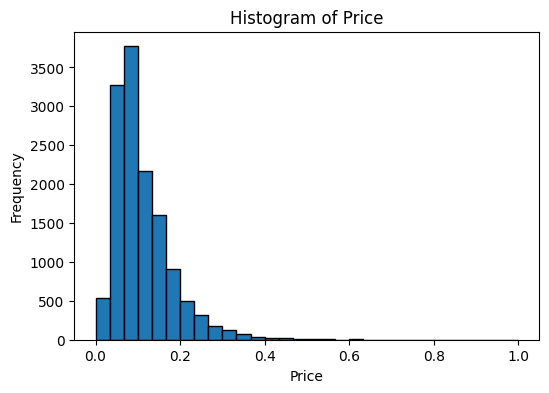

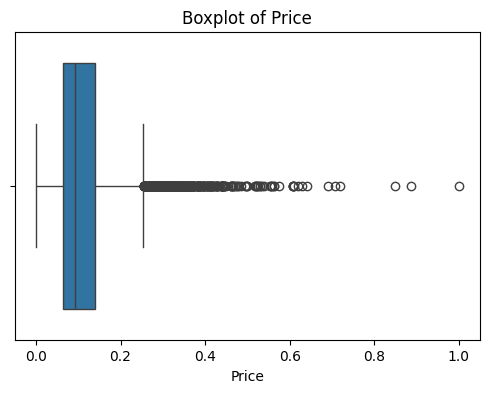

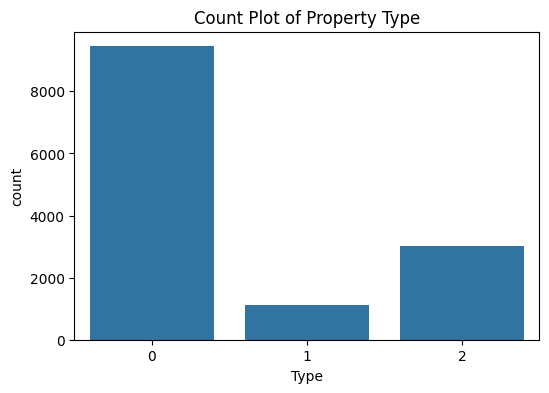

In [8]:
# 6. Univariate Analysis (3 Visualizations)

# Histogram
plt.figure(figsize=(6,4))
plt.hist(df['Price'], bins=30, edgecolor='black')
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")
plt.show()

# Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x=df['Type'])
plt.title("Count Plot of Property Type")
plt.show()



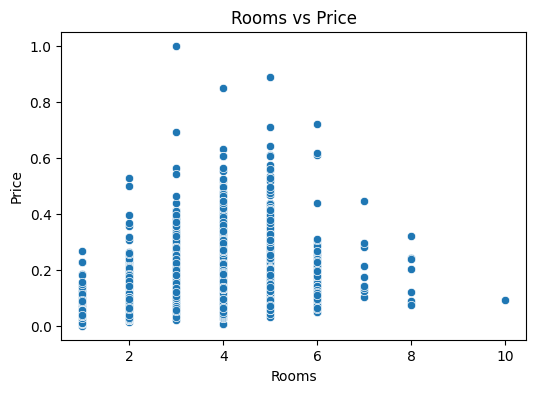

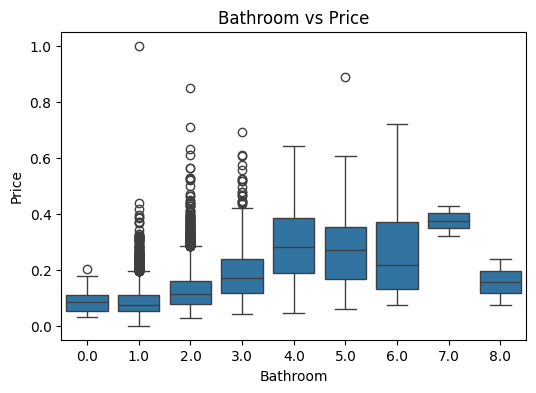

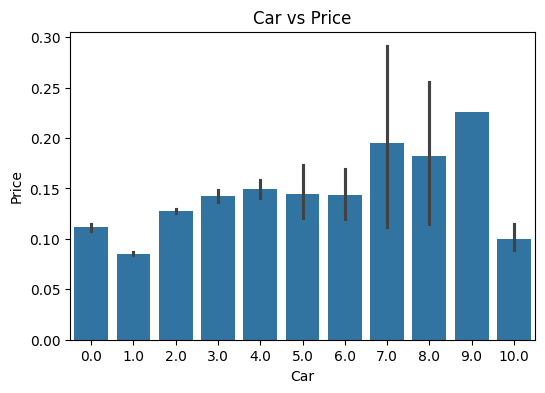

In [9]:
# 7. Bivariate Analysis (3 Visualizations)

# Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='Rooms', y='Price', data=df)
plt.title("Rooms vs Price")
plt.show()

# Box Plot
plt.figure(figsize=(6,4))
sns.boxplot(x='Bathroom', y='Price', data=df)
plt.title("Bathroom vs Price")
plt.show()

# Bar Plot
plt.figure(figsize=(6,4))
sns.barplot(x='Car', y='Price', data=df)
plt.title("Car vs Price")
plt.show()



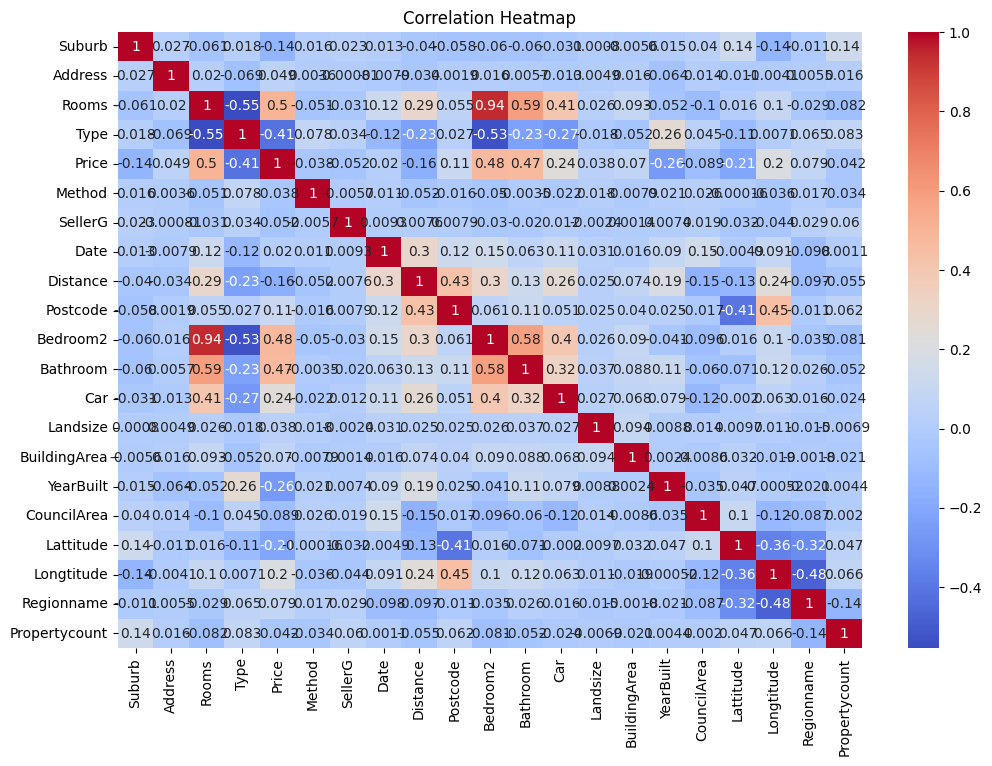

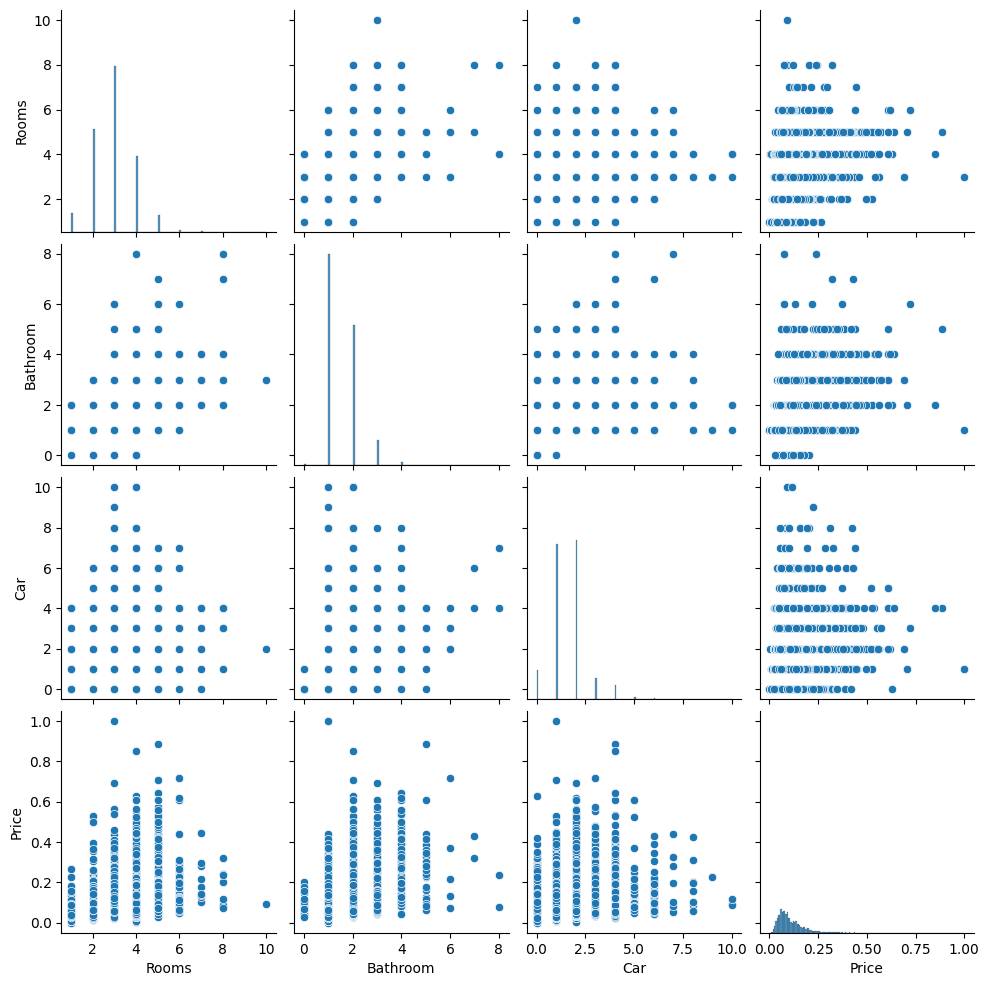

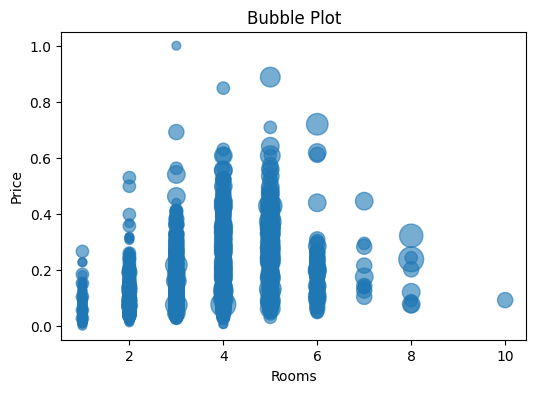

In [10]:
# 8. Multivariate Analysis (3 Visualizations)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Pair Plot
sns.pairplot(df[['Rooms','Bathroom','Car','Price']])
plt.show()

# Bubble Plot
plt.figure(figsize=(6,4))
plt.scatter(df['Rooms'], df['Price'],
            s=df['Bathroom']*40,
            alpha=0.6)

plt.xlabel("Rooms")
plt.ylabel("Price")
plt.title("Bubble Plot")
plt.show()



In [12]:
# Final Output

print("\nFinal Dataset Shape:", df.shape)

print("\nFirst Five Rows of Final Dataset")
print(df.head())


Final Dataset Shape: (13580, 21)

First Five Rows of Final Dataset
   Suburb  Address  Rooms  Type     Price  Method  SellerG  Date  Distance  \
0       0    12794      2     0  0.156478       1       23    29       2.5   
1       0     5943      2     0  0.106562       1       23     1       2.5   
2       0     9814      3     0  0.154795       3       23    33       2.5   
3       0     9004      3     0  0.085810       0       23    33       2.5   
4       0    10589      4     0  0.169938       4      155     8       2.5   

   Postcode  ...  Bathroom  Car  Landsize  BuildingArea  YearBuilt  \
0    3067.0  ...       1.0  1.0     202.0         126.0     1970.0   
1    3067.0  ...       1.0  0.0     156.0          79.0     1900.0   
2    3067.0  ...       2.0  0.0     134.0         150.0     1900.0   
3    3067.0  ...       2.0  1.0      94.0         126.0     1970.0   
4    3067.0  ...       1.0  2.0     120.0         142.0     2014.0   

   CouncilArea  Lattitude  Longtitude  Reg